# Machine Learning Model Training and Evaluation
Train multiple regression models and compare their performance.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [2]:
df = pd.read_csv('simulation_dataset.csv')
X = df[['velocity','angle']]
y = df['range']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor()
}

In [4]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results.append([name, r2, rmse])

results_df = pd.DataFrame(results, columns=['Model','R2 Score','RMSE'])
results_df.to_csv('model_metrics.csv', index=False)
results_df

,Model,R2 Score,RMSE
0,Linear Regression,0.755320,112.502296
1,Ridge Regression,0.755320,112.502302
2,Decision Tree,0.962525,44.028700
3,Random Forest,0.982292,30.265348
4,Gradient Boosting,0.980111,32.075154
5,SVR,0.556350,151.489532
6,KNN,0.981949,30.557029


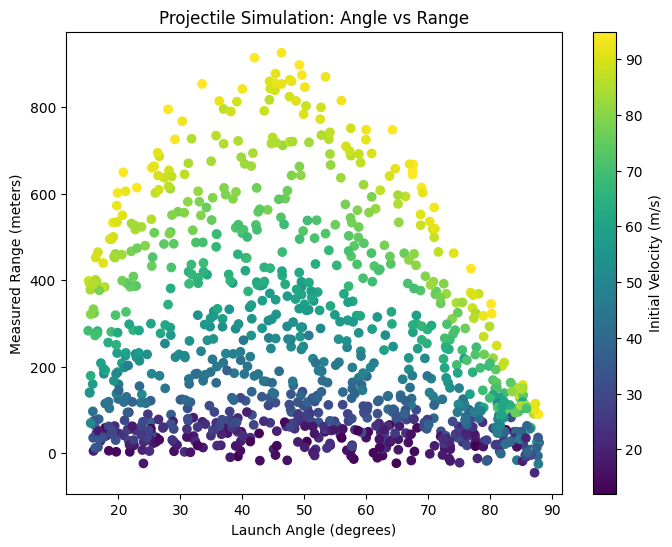

In [5]:
import matplotlib.pyplot as plt

df = pd.read_csv("simulation_dataset.csv")

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    df["angle"],
    df["range"],
    c=df["velocity"]
)

plt.xlabel("Launch Angle (degrees)")
plt.ylabel("Measured Range (meters)")
plt.title("Projectile Simulation: Angle vs Range")
plt.colorbar(scatter, label="Initial Velocity (m/s)")

plt.show()


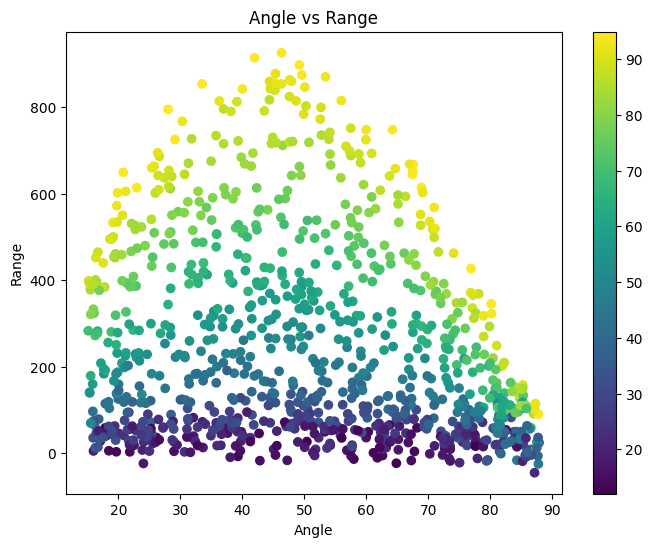

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("simulation_dataset.csv")

plt.figure(figsize=(8,6))
scatter = plt.scatter(df["angle"], df["range"], c=df["velocity"])

plt.xlabel("Angle")
plt.ylabel("Range")
plt.title("Angle vs Range")

plt.colorbar(scatter)
plt.savefig("physics_simulation_visual.png")
plt.show()


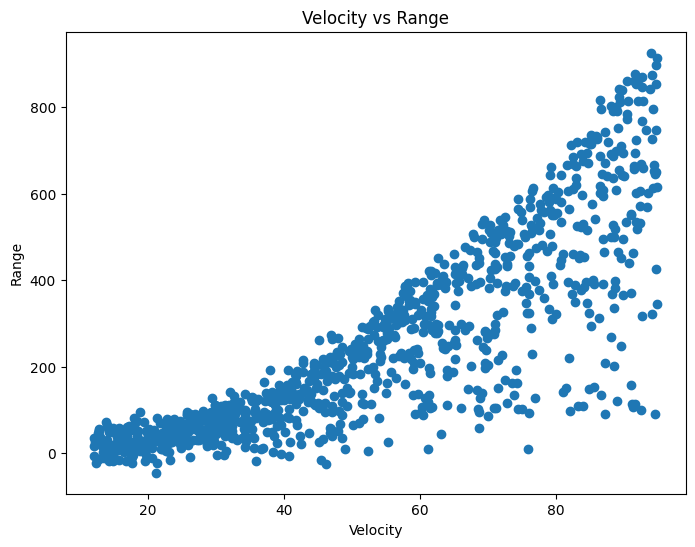

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(df["velocity"], df["range"])

plt.xlabel("Velocity")
plt.ylabel("Range")
plt.title("Velocity vs Range")

plt.savefig("velocity_range_relationship.png")
plt.show()


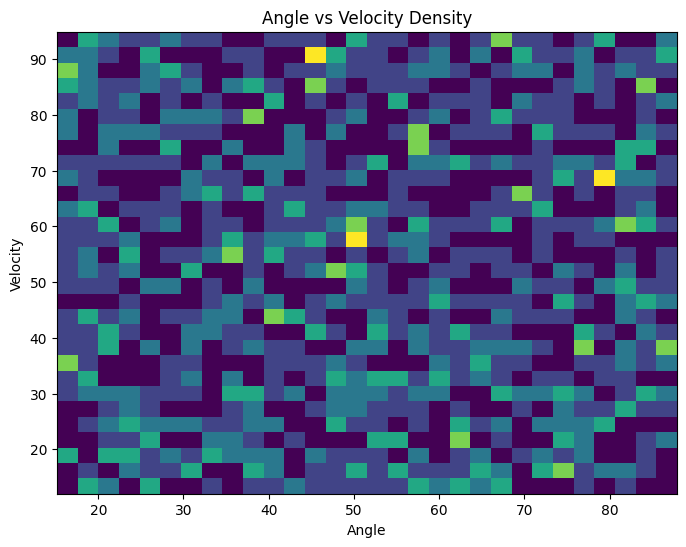

In [9]:
plt.figure(figsize=(8,6))
plt.hist2d(df["angle"], df["velocity"], bins=30)

plt.xlabel("Angle")
plt.ylabel("Velocity")
plt.title("Angle vs Velocity Density")

plt.savefig("angle_velocity_density.png")
plt.show()


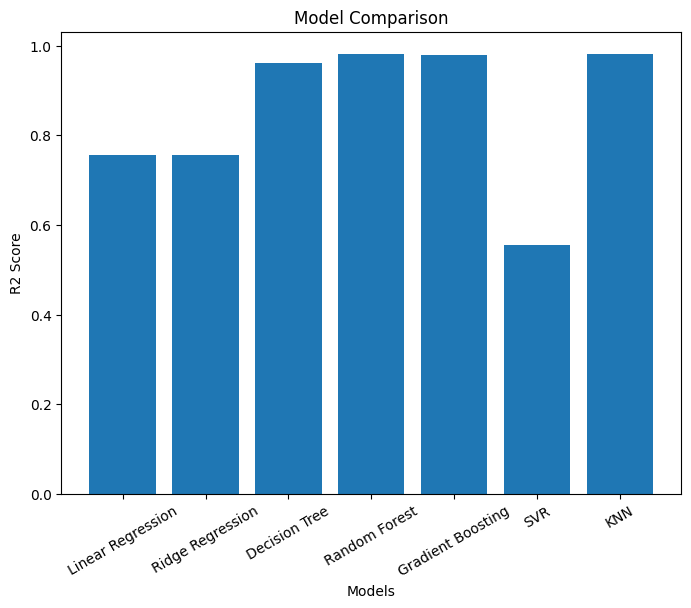

In [10]:
plt.figure(figsize=(8,6))
plt.bar(results_df["Model"], results_df["R2 Score"])

plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison")

plt.xticks(rotation=30)
plt.savefig("regression_model_comparison.png")
plt.show()


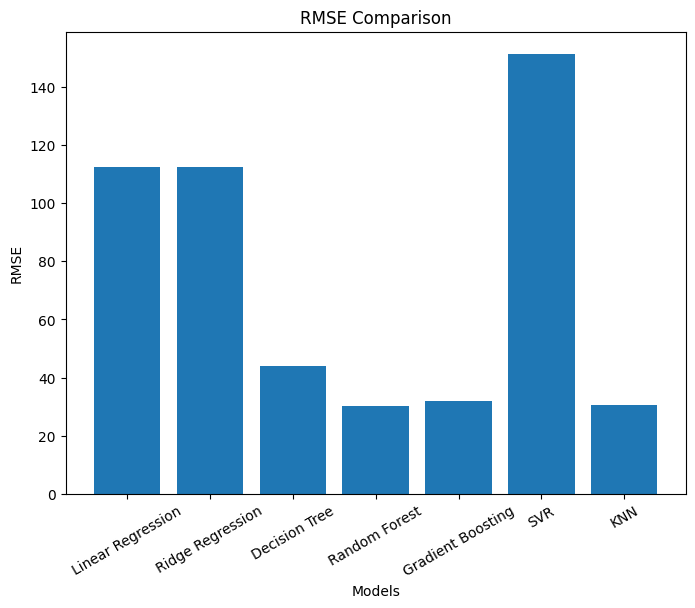

In [11]:
plt.figure(figsize=(8,6))
plt.bar(results_df["Model"], results_df["RMSE"])

plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("RMSE Comparison")

plt.xticks(rotation=30)
plt.savefig("rmse_model_comparison.png")
plt.show()


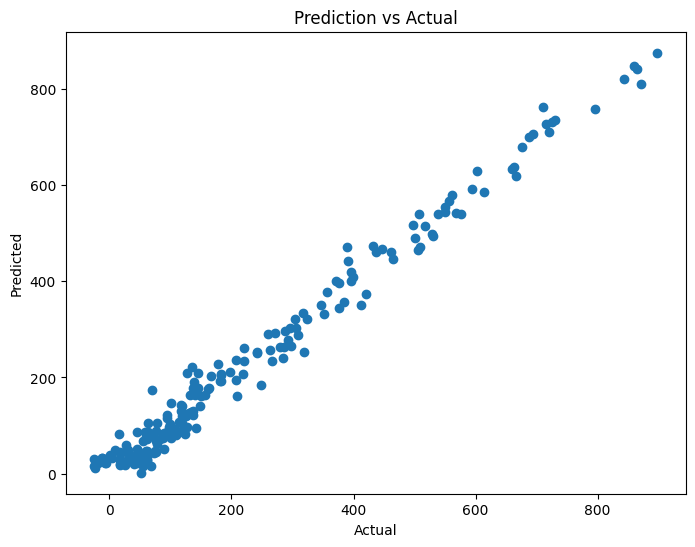

In [12]:
best_model_name = results_df.sort_values("R2 Score", ascending=False)["Model"].iloc[0]
best_model = models[best_model_name]

preds = best_model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, preds)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual")

plt.savefig("prediction_vs_actual.png")
plt.show()


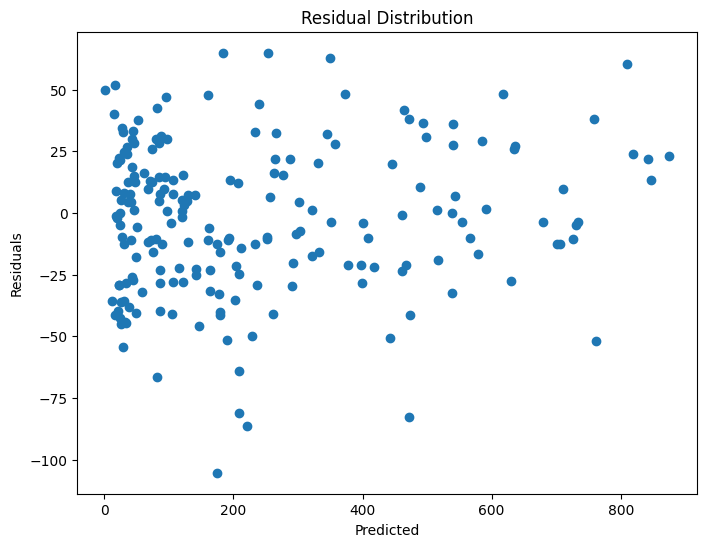

In [13]:
residuals = y_test - preds

plt.figure(figsize=(8,6))
plt.scatter(preds, residuals)

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Distribution")

plt.savefig("residual_error_distribution.png")
plt.show()


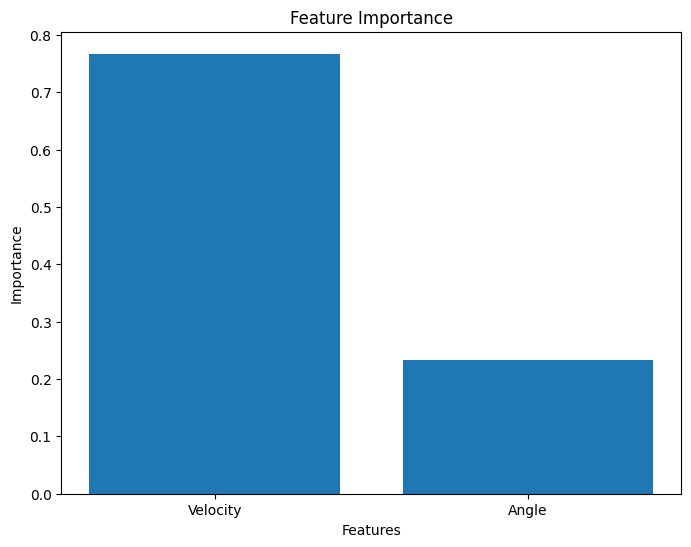

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

importance = rf.feature_importances_

plt.figure(figsize=(8,6))
plt.bar(["Velocity","Angle"], importance)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.savefig("feature_importance_plot.png")
plt.show()
